In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors

### Links zu den Package Dokumentationen
 - NumPy: https://numpy.org/doc/stable/
 - matplotlib: https://matplotlib.org/stable/users/index
 - pandas: https://pandas.pydata.org/docs/

## Datensätze

### Pilze

This data set includes descriptions of hypothetical samples
corresponding to 23 species of gilled mushrooms in the Agaricus and
Lepiota Family (pp. 500-525).  Each species is identified as
definitely edible, definitely poisonous, or of unknown edibility and
not recommended.  This latter class was combined with the poisonous
one.  The Guide clearly states that there is no simple rule for
determining the edibility of a mushroom; no rule like "leaflets three, let it be" for Poisonous Oak and Ivy.

Quelle: 
* Mushroom records drawn from The Audubon Society Field Guide to North American Mushrooms (1981). G. H. Lincoff (Pres.), New York: Alfred A. Knopf
   
* Donor: Jeff Schlimmer (Jeffrey.Schlimmer@a.gp.cs.cmu.edu)

* Date: 27 April 1987

* heruntergeladen von https://archive.ics.uci.edu/ml/datasets/mushroom und bearbeitet

### Penguin

Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

heruntergeladen von https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data und bearbeitet

In [7]:
# Anpassen der Speicherorte nicht vergessen!
mush = pd.read_excel('mushroom-colors.xlsx', index_col=0)
penguins = pd.read_excel('penguinsSmall.xlsx', index_col=0)

## Pakete für Visualisierungen

Matplotlib Beispiele: https://matplotlib.org/stable/gallery/index.html

Seaborn Beispiele: http://seaborn.pydata.org/examples/index.html

# Grundlegende Darstellungsformen

## Punkte-Diagramm (Scatter Plot) 

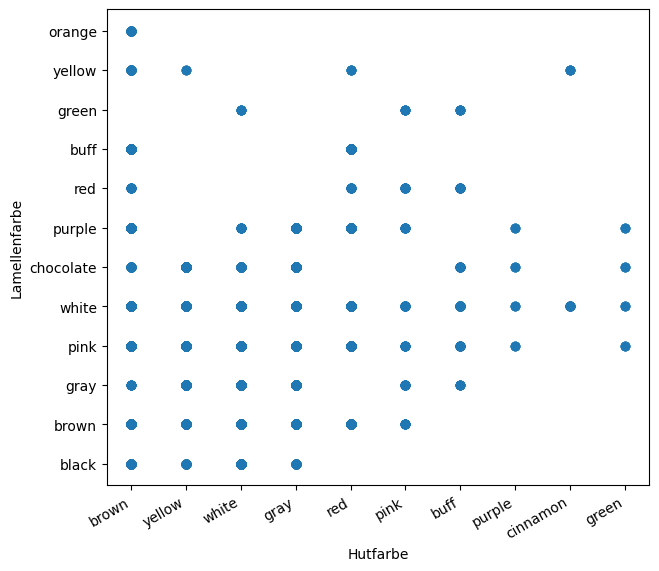

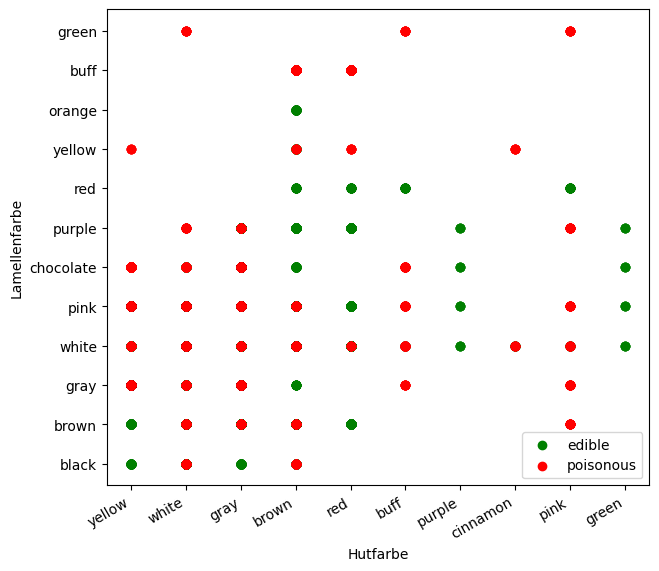

In [15]:
fig = plt.figure(figsize=(7,7))
ax1 = fig.add_subplot(111)
ax1.scatter(mush['Hutfarbe'], mush['Lamellenfarbe'])
ax1.set_xlabel('Hutfarbe')
ax1.set_ylabel('Lamellenfarbe')
fig.autofmt_xdate()
plt.show()

# define colors for edible and poisonous
cDict = {'edible':'green','poisonous':'red'}

fig = plt.figure(figsize=(7,7))
ax2 = fig.add_subplot(111)
for group in mush.groupby('Klasse'):
    ax2.scatter(group[1]['Hutfarbe'], group[1]['Lamellenfarbe'], color=cDict[group[0]], label=group[0])
ax2.set_xlabel('Hutfarbe')
ax2.set_ylabel('Lamellenfarbe')
ax2.legend()
fig.autofmt_xdate()
plt.show()

**Frage**: Welche Information ist hier *nicht* sichtbar?

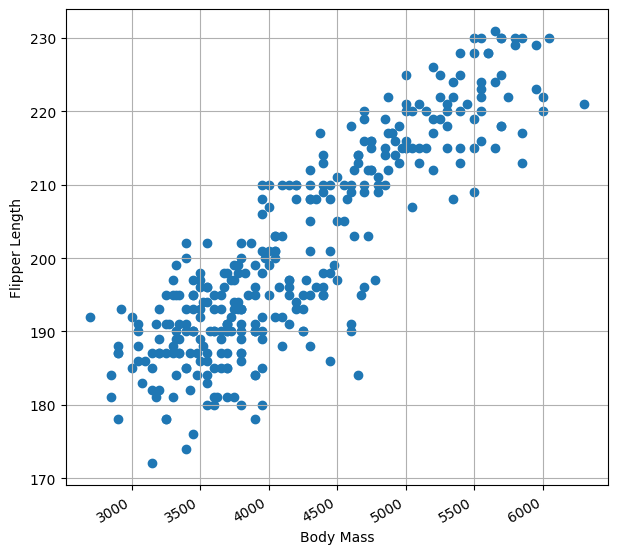

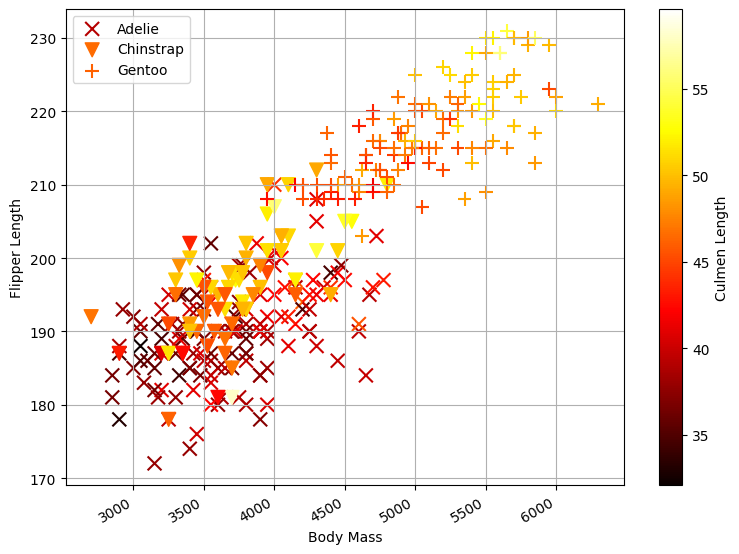

In [9]:
fig = plt.figure(figsize=(7,7))
ax1 = fig.add_subplot(111)
ax1.scatter(penguins['Body Mass (g)'], penguins['Flipper Length (mm)'])
ax1.set_xlabel('Body Mass')
ax1.set_ylabel('Flipper Length')
ax1.grid()
fig.autofmt_xdate()
plt.show()

# mapping of culmen length into color-scale
minC = penguins['Culmen Length (mm)'].min()
maxC = penguins['Culmen Length (mm)'].max()
norm = colors.Normalize(vmin=minC, vmax=maxC, clip=True)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.hot)

# mapping of species into markers
mDict = {'Adelie':'x', 'Gentoo':'+','Chinstrap':'v'}

fig = plt.figure(figsize=(9,7))
ax2 = fig.add_subplot(111)
for group in penguins.groupby('Species'):
    ax2.scatter(group[1]['Body Mass (g)'], group[1]['Flipper Length (mm)'],\
                c=mapper.to_rgba(group[1]['Culmen Length (mm)']), label=group[0],\
                marker=mDict[group[0]], s=100)
ax2.set_xlabel('Body Mass')
ax2.set_ylabel('Flipper Length')
ax2.grid()
ax2.legend()
fig.colorbar(mapper, ax=ax2, label='Culmen Length')
fig.autofmt_xdate()
plt.show()


### Eigenschaften
- Zusammenhang zwischen zwei Merkmalen
- Prinzip der Ähnlichkeit: Punkte die "ähnlich" aussehen werden als "ähnlich" aufgefasst
- Einbezug weiterer Merkmale: Farbe, Marker, Größe

Dokumentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html

## Balkengraphen (Bar Plot)

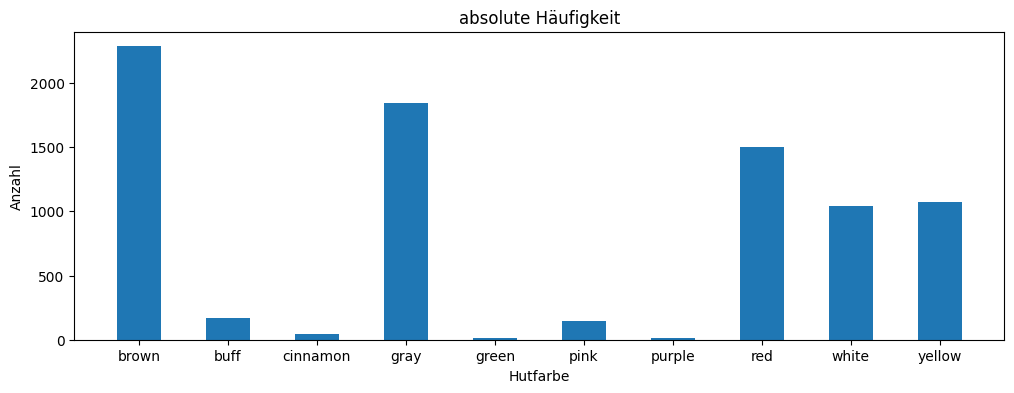

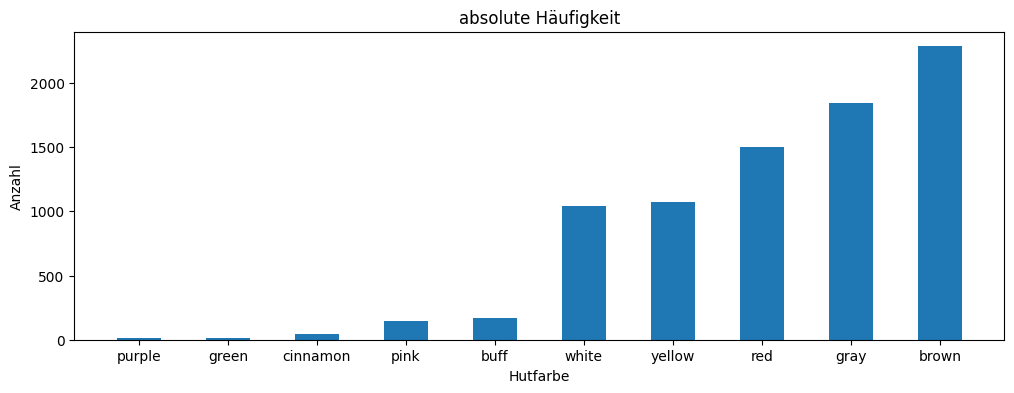

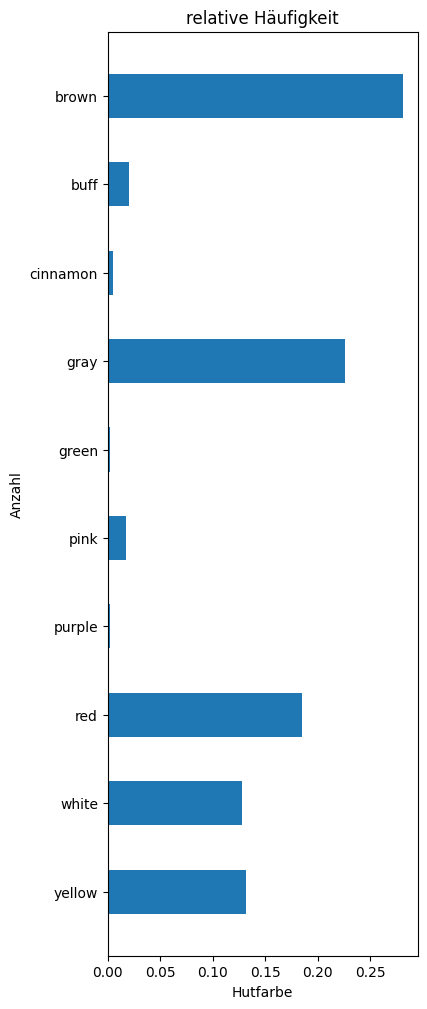

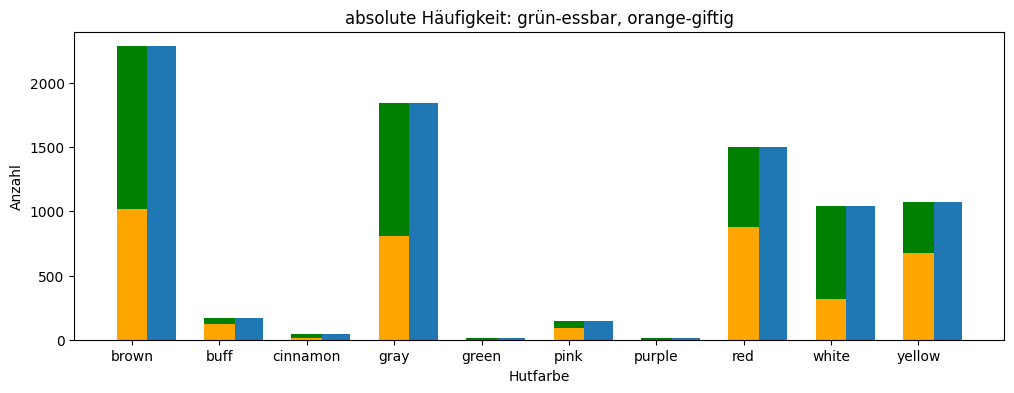

In [10]:
colors = mush['Hutfarbe'].value_counts()
colors = colors.sort_index()

fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(111)
ax1.bar(range(0,len(colors)), height=colors.values, width=0.5, align='center', tick_label=colors.index)
ax1.set_title('absolute Häufigkeit')
ax1.set_xlabel('Hutfarbe')
ax1.set_ylabel('Anzahl')
plt.show()

colors2 = colors.sort_values()
fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(111)
ax1.bar(range(0,len(colors)), height=colors2.values, width=0.5, align='center', tick_label=colors2.index)
ax1.set_title('absolute Häufigkeit')
ax1.set_xlabel('Hutfarbe')
ax1.set_ylabel('Anzahl')
plt.show()

fig = plt.figure(figsize=(4,12))
ax1 = fig.add_subplot(111)
ax1.barh(range(0,len(colors)), width=colors.values/sum(colors.values), height=0.5, align='center', tick_label=colors.index)
ax1.set_title('relative Häufigkeit')
ax1.set_xlabel('Hutfarbe')
ax1.set_ylabel('Anzahl')
ax1.invert_yaxis()
plt.show()

# determine number of edible and poisonous mushrooms
p = list()
e = list()
for color in colors.index:
    df = mush[mush['Hutfarbe']==color]
    p.append(sum(df['Klasse']=='poisonous'))
    e.append(sum(df['Klasse']=='edible'))

fig = plt.figure(figsize=(12,4))
ax1 = fig.add_subplot(111)
ax1.bar(range(0,len(colors)), height=colors.values, width=0.5, align='edge', tick_label=colors.index)
ax1.bar(range(0,len(colors)), height=p, width=0.35, align='center', tick_label=colors.index, color='orange')
ax1.bar(range(0,len(colors)), height=e, width=0.35, align='center', tick_label=colors.index, color='green', bottom=p)
ax1.set_title('absolute Häufigkeit: grün-essbar, orange-giftig')
ax1.set_xlabel('Hutfarbe')
ax1.set_ylabel('Anzahl')
plt.show()

### Eigenschaften:
- kann sowohl für strukturelle Eigenschaften als auch für Zeitreihen benutzt werden 
- zeitlicher Verlauf wird **immer** auf der horizontalen Achse dargestellt
- verschiedene Varianten existieren: zusammengesetzt, Ausprägungen von einer Nullinie, gruppiert, kumuliert, ...
- anstatt Balken können auch Stäbe (=Linie) verwendet werden (z.B. für diskrete Werte)
- *Hinweis*: Balken sollten gleiche Breite haben
- Einbezug weiterer Merkmale: Farbe
- bei gestapelten Balken ist die Analyse der Verteilung der Merkmalsausprägungen nicht mehr ablesbar

Dokumentation:
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.barh.html

## Liniengraphen (Line Plots)

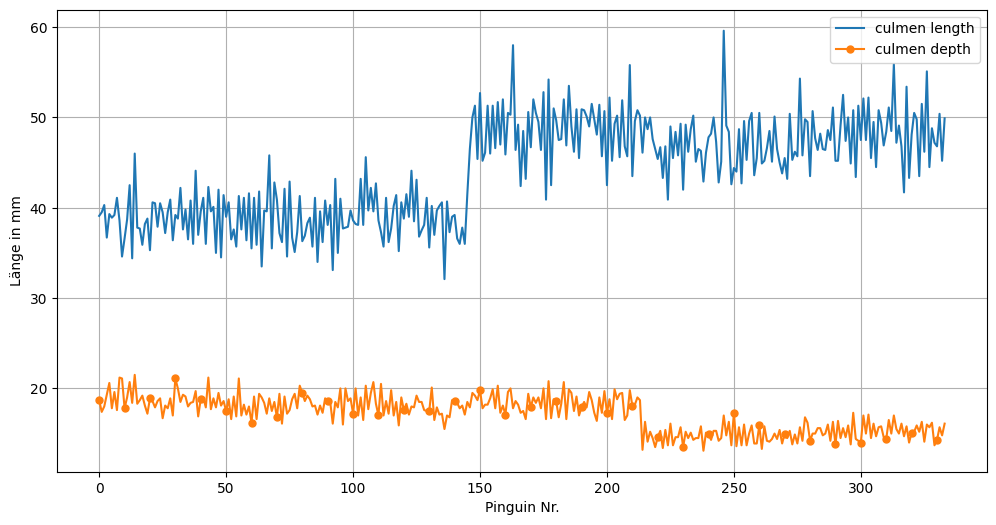

In [11]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)
ax.plot(range(penguins.shape[0]), penguins['Culmen Length (mm)'], label='culmen length')
ax.plot(range(penguins.shape[0]), penguins['Culmen Depth (mm)'], label='culmen depth',\
        marker='o', markevery=10, markersize=5)
ax.grid()
ax.set_xlabel('Pinguin Nr.')
ax.set_ylabel('Länge in mm')
ax.legend()
plt.show()

### Eigenschaften
- erlaubt den Vergleich verschiedener Datenreihen (strukturell und zeitlich)
- Linien erzeugen Eindruck eines Zusammenhanges (z.B. Verlauf, Kontinuität)
- *Hinweis*: nicht zuviele Linien im Diagramm
- Einbezug weiterer Merkmale: Farbe, Linienart, Marker

Dokumentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

# Spezielle Darstellungen

## Histogramm 

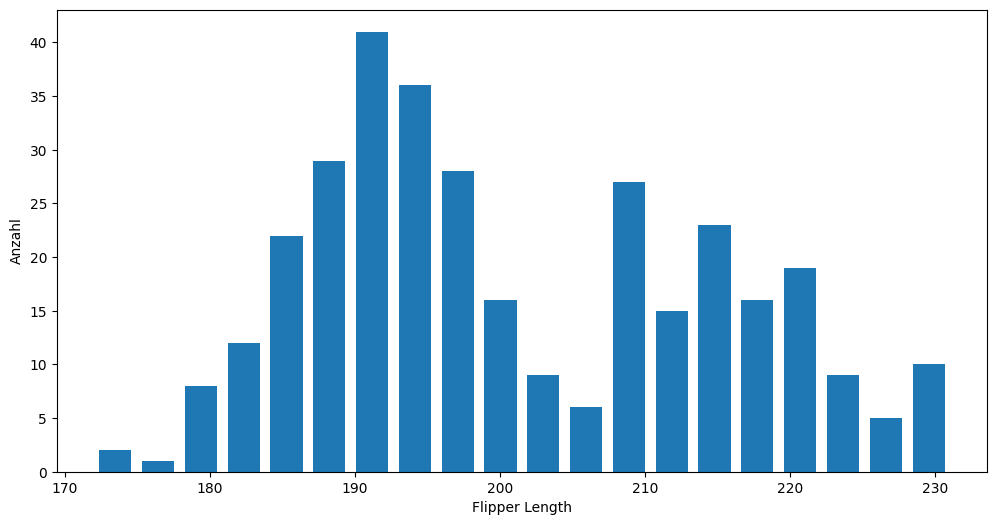

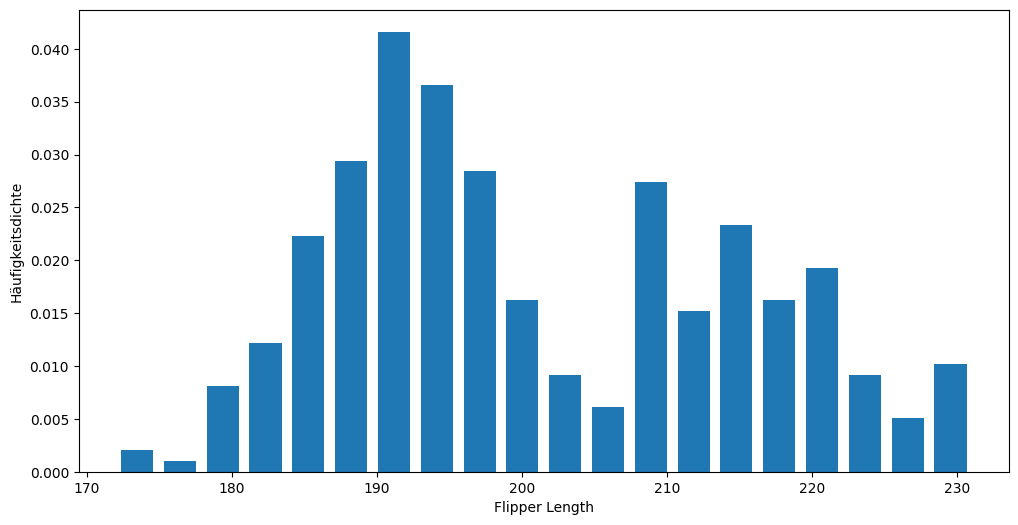

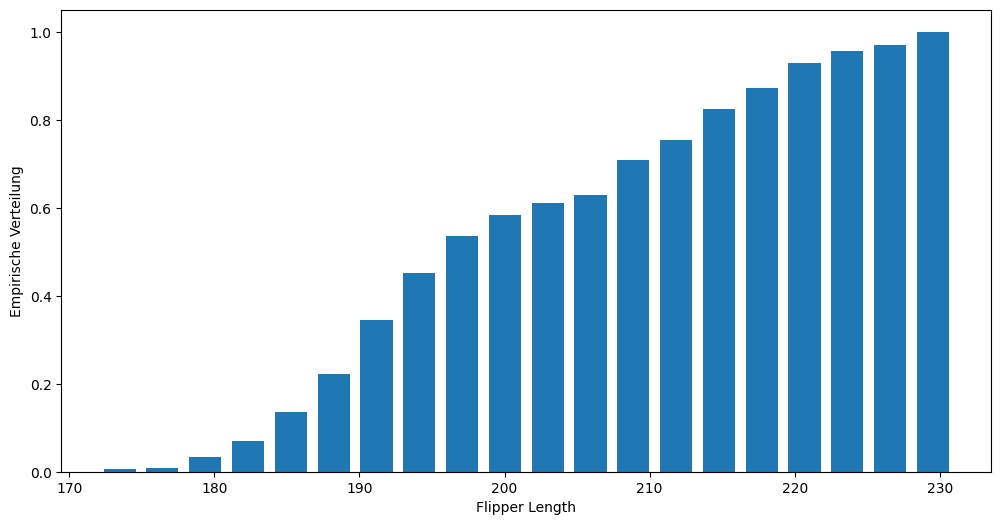

In [12]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)
ax.hist(penguins['Flipper Length (mm)'], bins=20, rwidth=0.75)
ax.set_xlabel('Flipper Length')
ax.set_ylabel('Anzahl')
plt.show()

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)
ax.hist(penguins['Flipper Length (mm)'], bins=20, density=True, rwidth=0.75)
ax.set_xlabel('Flipper Length')
ax.set_ylabel('Häufigkeitsdichte')
plt.show()

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)
ax.hist(penguins['Flipper Length (mm)'], bins=20, density=True, cumulative=True, rwidth=0.75)
ax.set_xlabel('Flipper Length')
ax.set_ylabel('Empirische Verteilung')
plt.show()

Dokumentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

## Tortendiagramm (Pie Chart)

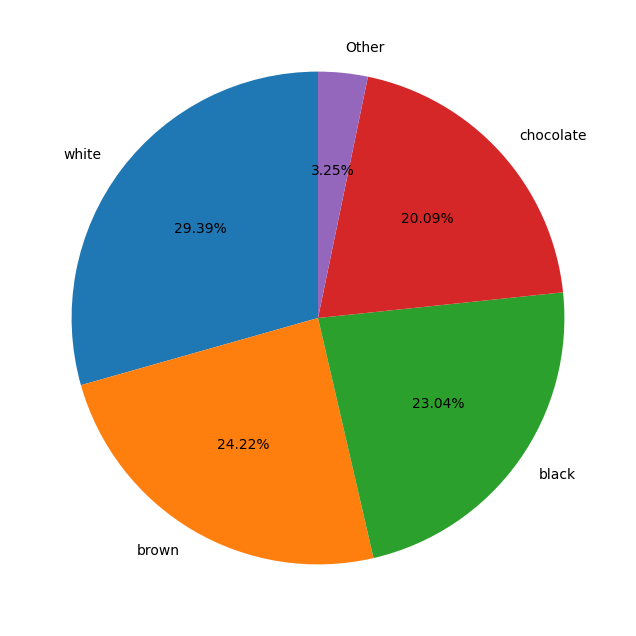

In [13]:
colors = mush['Sporenpulverfarbe'].value_counts()
colors = colors.sort_values(ascending=False)
# aggregate colors with very few samples
colorsAgg = colors.iloc[:4]
colorsAgg.loc['Other'] = colors.iloc[4:].sum()

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
ax.pie(colorsAgg.values, normalize=True, labels=colorsAgg.index, startangle=90, autopct='%1.2f%%')
plt.show()


Dokumentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html

## Box Plot

C:\Users\Mathias Lampert\AppData\Local\Temp\ipykernel_1696\2181590681.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group['Body Mass (g)'], labels=[name], positions=[p])
C:\Users\Mathias Lampert\AppData\Local\Temp\ipykernel_1696\2181590681.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group['Body Mass (g)'], labels=[name], positions=[p])
C:\Users\Mathias Lampert\AppData\Local\Temp\ipykernel_1696\2181590681.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(group['Body Mass (g)'], labels=[name], positions=[p])


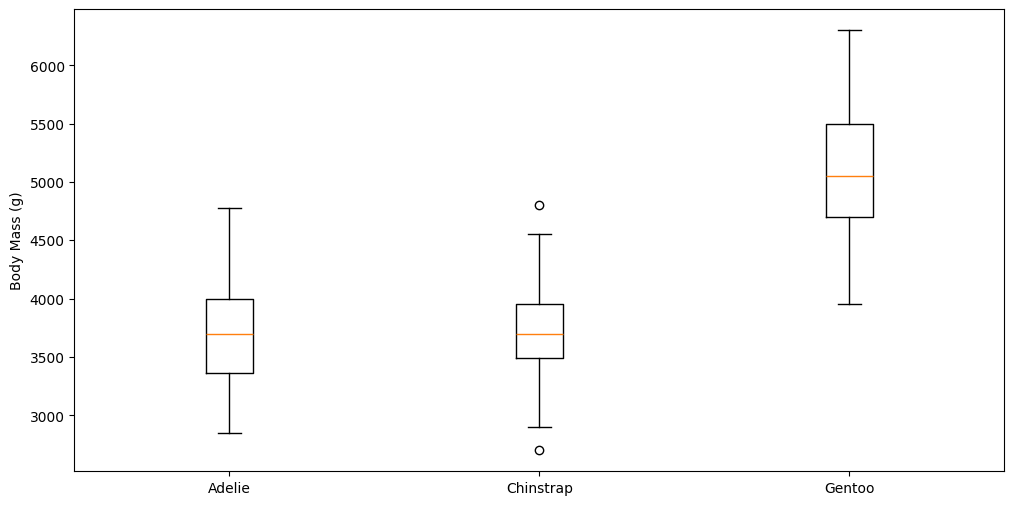

In [14]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)
p = 1
for name, group in penguins.groupby('Species'):
    ax.boxplot(group['Body Mass (g)'], labels=[name], positions=[p])
    p += 1
ax.set_ylabel('Body Mass (g)')
plt.show()

Definition der *Box*:
- orange Linie ist der Median
- obere/untere Kante der Box ist das obere/untere Quartil
- Box ist der Interquartilsabstand (IQR)
- Whiskers: 
    - unteres Ende: Ausprägung die >= unteres Quartil - 1.5*IQR 
    - oberes Ende: Ausprägung <= oberes Quartil + 1.5*IQR 
- Punkte über/unter den Whiskers sind Ausreißer

Eigenschaften:
- erlaubt einen Vergleich der Verteilungen unter Einbeziehung von Lagemassen (Median, Mittelwert) und Streumaßen
- erkennbar ob Verteilungen symmetrisch oder *schief* sind
- Multimodalität ist jedoch nicht sichtbar
    
    
- Erweiterung: Violin Plots (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.violinplot.html)

Dokumentation:https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html